# V2 + WBC 裁剪 + **增强 + 过采样**（训练集）

与 `pipeline_v2_wbc_crop.ipynb` 相同特征与 XGBoost 超参，区别：

1. **验证集**：每张图 **1 条** 特征（裁剪 → resize 64 → v2），**无增强、无过采样**。
2. **训练折 / 全量训练**：先对 **该折训练表** 做 **类均衡过采样**（不足 `OVERSAMPLE_MIN_PER_CLASS` 的类有放回重复到目标条数），再对 **每条图像行** 在 **裁剪后、resize 前** 生成 `N_AUG` 条增强图（aug_id 0=原图，1=小角度旋转，2=水平翻转，3=旋转90°，4=HSV 轻微抖动），每条提 718 维特征。
3. **`sample_weight='balanced'`** 在 **展开后的 y** 上计算。

**注意**：训练特征量约为 `过采样后行数 × N_AUG`，耗时明显增加。可将 `OVERSAMPLE_MIN_PER_CLASS=None` 关闭过采样，或减小 `N_AUG`。

**提交**：`submission_v2_wbc_crop2_aug_os_xgboost.csv`（`crop1` 时为 `crop1` 后缀）。


In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
from tqdm import tqdm
from PIL import Image

import cv2
import matplotlib.pyplot as plt
import seaborn as sns

from skimage.transform import resize
from skimage.feature import hog, local_binary_pattern
from skimage.color import rgb2hsv, rgb2gray, rgb2lab
from skimage.measure import moments_hu, label as sk_label, regionprops
from skimage.morphology import binary_opening, binary_closing, disk
from skimage.filters import threshold_otsu
from scipy.stats import skew, kurtosis
from scipy.ndimage import binary_fill_holes

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.utils.class_weight import compute_sample_weight
from joblib import Parallel, delayed
from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=UserWarning)

ROOT_DIR = "./"
TRAIN_DIR = os.path.join(ROOT_DIR, "train")
TEST_DIR = os.path.join(ROOT_DIR, "test")
TRAIN_META = os.path.join(ROOT_DIR, "train_metadata.csv")
TEST_META = os.path.join(ROOT_DIR, "test_metadata.csv")

# ========== 与 v2 一致 ==========
IMG_SIZE = 128 #(220*220)

# --- aug / oversample ---
AUG_SEED = 42
# 每图 N 种增强（aug_id 0..N_AUG-1，含原图）
N_AUG = 4
# 每类至少多少行；不足则随机有放回重复。None = 不过采样
OVERSAMPLE_MIN_PER_CLASS = 400



In [5]:
train_df = pd.read_csv(TRAIN_META)
test_df = pd.read_csv(TEST_META)

le = LabelEncoder()
y_train = le.fit_transform(train_df["label"])

print("训练样本:", len(train_df), "| 类别数:", len(le.classes_))
print(train_df["label"].value_counts())




训练样本: 28901 | 类别数: 13
label
SNE    13015
LY      8101
MO      2746
BL      2012
EO       861
MY       441
BA       415
BNE      391
VLY      366
MMY      360
PMY      114
PC        68
PLY       11
Name: count, dtype: int64


In [ ]:
# # ---------- WBC 裁剪 (OpenCV) — 输入/输出均为 RGB uint8 ----------


# def largest_component(mask: np.ndarray) -> np.ndarray:
#     num, lab, stats, _ = cv2.connectedComponentsWithStats(mask.astype(np.uint8), connectivity=8)
#     if num <= 1:
#         return mask.astype(np.uint8)
#     areas = stats[1:, cv2.CC_STAT_AREA]
#     best = 1 + np.argmax(areas)
#     return (lab == best).astype(np.uint8)


# def extract_wbc_crop(img_rgb: np.ndarray) -> np.ndarray:
#     hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
#     H, S, V = hsv[:, :, 0], hsv[:, :, 1], hsv[:, :, 2]

#     nuc = ((S > 60) & (V < 170) & (H > 110) & (H < 170)).astype(np.uint8)

#     nuc = cv2.medianBlur(nuc * 255, 5)
#     nuc = (nuc > 0).astype(np.uint8)

#     nuc = largest_component(nuc)

#     kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (45, 45))
#     mask = cv2.dilate(nuc, kernel)

#     ys, xs = np.where(mask > 0)
#     if len(xs) == 0:
#         return img_rgb

#     x1, x2 = xs.min(), xs.max()
#     y1, y2 = ys.min(), ys.max()

#     pad = 20
#     x1 = max(0, x1 - pad)
#     y1 = max(0, y1 - pad)
#     x2 = min(img_rgb.shape[1], x2 + pad)
#     y2 = min(img_rgb.shape[0], y2 + pad)

#     return img_rgb[y1:y2, x1:x2]


# def extract_wbc_crop2(
#     img_rgb: np.ndarray,
#     pad: int = 20,
#     min_area_frac: float = 0.0005,
#     q: float = 0.92,
# ) -> np.ndarray:
#     hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV).astype(np.float32)
#     H = hsv[:, :, 0]
#     S = hsv[:, :, 1]
#     V = hsv[:, :, 2]

#     hdist = np.minimum(np.abs(H - 140.0), 180.0 - np.abs(H - 140.0)) / 90.0
#     hscore = 1.0 - np.clip(hdist, 0.0, 1.0)
#     sscore = np.clip((S - 30.0) / 225.0, 0.0, 1.0)
#     vscore = 1.0 - np.clip(V / 255.0, 0.0, 1.0)

#     score = 0.55 * hscore + 0.25 * sscore + 0.20 * vscore
#     thr = float(np.quantile(score, q))
#     nuc = (score >= thr).astype(np.uint8)

#     nuc = cv2.medianBlur(nuc * 255, 5)
#     nuc = (nuc > 0).astype(np.uint8)

#     k1 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
#     nuc = cv2.morphologyEx(nuc, cv2.MORPH_OPEN, k1, iterations=1)
#     nuc = cv2.morphologyEx(nuc, cv2.MORPH_CLOSE, k1, iterations=2)

#     num, lab, stats, _ = cv2.connectedComponentsWithStats(nuc.astype(np.uint8), connectivity=8)
#     if num <= 1:
#         return img_rgb

#     h, w = nuc.shape
#     min_area = int(min_area_frac * h * w)

#     cx0, cy0 = w * 0.5, h * 0.5
#     best_i = None
#     best_score = -1e18
#     for i in range(1, num):
#         area = int(stats[i, cv2.CC_STAT_AREA])
#         if area < min_area:
#             continue
#         cx = float(stats[i, cv2.CC_STAT_LEFT] + 0.5 * stats[i, cv2.CC_STAT_WIDTH])
#         cy = float(stats[i, cv2.CC_STAT_TOP] + 0.5 * stats[i, cv2.CC_STAT_HEIGHT])
#         d2 = (cx - cx0) ** 2 + (cy - cy0) ** 2
#         s = np.log1p(area) - 0.0008 * d2
#         if s > best_score:
#             best_score = s
#             best_i = i

#     if best_i is None:
#         return img_rgb

#     nuc = (lab == best_i).astype(np.uint8)

#     kbig = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (45, 45))
#     mask = cv2.dilate(nuc, kbig, iterations=1)

#     ys, xs = np.where(mask > 0)
#     if xs.size == 0:
#         return img_rgb

#     x1, x2 = int(xs.min()), int(xs.max())
#     y1, y2 = int(ys.min()), int(ys.max())

#     x1 = max(0, x1 - pad)
#     y1 = max(0, y1 - pad)
#     x2 = min(img_rgb.shape[1], x2 + pad)
#     y2 = min(img_rgb.shape[0], y2 + pad)

#     if (x2 - x1) < 10 or (y2 - y1) < 10:
#         return img_rgb

#     return img_rgb[y1:y2, x1:x2]


# # def apply_wbc_crop(img_rgb: np.ndarray) -> np.ndarray:
# #     if CROP_METHOD == "crop1":
# #         return extract_wbc_crop(img_rgb)
# #     if CROP_METHOD == "crop2":
# #         return extract_wbc_crop2(img_rgb)
# #     raise ValueError("CROP_METHOD 应为 'crop1' 或 'crop2'")




In [6]:
def apply_wbc_crop_robust(img_rgb: np.ndarray, fixed_size: int = 220) -> np.ndarray:
    """
    稳健版裁剪：
    1. 寻找核的质心 (Centroid)
    2. 以质心为中心，裁剪一个固定大小 (fixed_size) 的正方形
    3. 自动处理边缘越界情况 (Padding)
    """
    h, w = img_rgb.shape[:2]
    img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    
    # 1. 提取核掩膜 (稍微放宽一点阈值)
    mask = ((img_hsv[:, :, 1] > 50) & (img_hsv[:, :, 2] < 190)).astype(np.uint8) * 255
    
    # 2. 形态学清理 (去除杂质，连接核碎片)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # 3. 连通域分析
    num, labels, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=8)
    
    if num <= 1:
        return img_rgb # 没找到则返回原图

    # 4. 中心偏置算法：找到最靠近图中心且面积达标的物体
    img_center = np.array([w / 2, h / 2])
    best_idx = -1
    min_dist = float('inf')
    
    for i in range(1, num):
        area = stats[i, cv2.CC_STAT_AREA]
        if area < 400: continue # 过滤小噪点
        
        dist = np.linalg.norm(centroids[i] - img_center)
        if dist < min_dist:
            min_dist = dist
            best_idx = i

    if best_idx == -1: return img_rgb

    # 5. 【核心优化】以核质心为中心点进行正方形裁剪
    cx, cy = centroids[best_idx]
    cx, cy = int(cx), int(cy)
    
    # 计算裁剪边界 (边长为 fixed_size)
    half_s = fixed_size // 2
    x1, x2 = cx - half_s, cx + half_s
    y1, y2 = cy - half_s, cy + half_s

    # 6. 处理越界：如果框伸到了图外面，进行平移而不是直接截断
    if x1 < 0:
        x2 -= x1 # 向右平移
        x1 = 0
    if y1 < 0:
        y2 -= y1 # 向下平移
        y1 = 0
    if x2 > w:
        x1 -= (x2 - w) # 向左平移
        x2 = w
    if y2 > h:
        y1 -= (y2 - h) # 向上平移
        y2 = h

    # 再次检查边界（极端情况下图片比 fixed_size 还小）
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(w, x2), min(h, y2)

    return img_rgb[y1:y2, x1:x2]

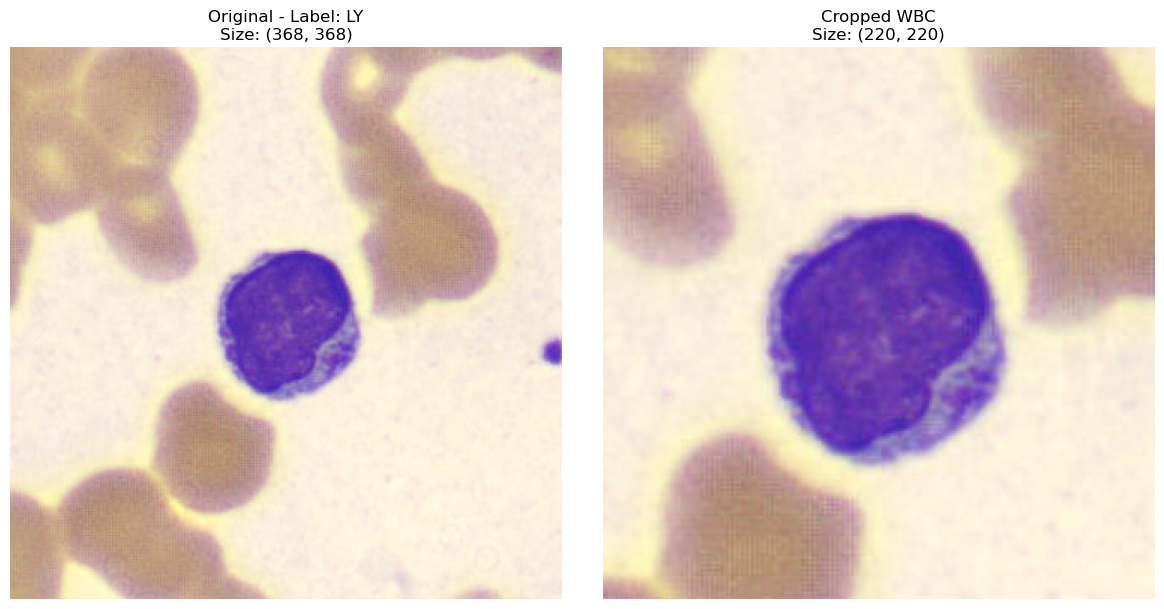

原图分辨率: 368x368
裁剪后分辨率: 220x220


In [77]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import os

# 1. 挑选一张图片（比如第一张，或者随机挑一张）
random_index = np.random.randint(0, len(train_df))
sample_row = train_df.iloc[random_index]  # 取第一行
image_id = sample_row['ID']
label = sample_row['label']
image_path = os.path.join(TRAIN_DIR, image_id)

# 2. 加载图片并转为 RGB 数组
raw_img = Image.open(image_path).convert("RGB")
img_rgb = np.array(raw_img)

# 3. 调用我们刚刚重写的裁剪函数
cropped_img = apply_wbc_crop_robust(img_rgb, fixed_size=220)

# 4. 可视化对比
plt.figure(figsize=(12, 6))

# 左侧：原始图
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title(f"Original - Label: {label}\nSize: {img_rgb.shape[:2]}")
plt.axis('off')

# 右侧：裁剪后的图
plt.subplot(1, 2, 2)
plt.imshow(cropped_img)
plt.title(f"Cropped WBC\nSize: {cropped_img.shape[:2]}")
plt.axis('off')

plt.tight_layout()
plt.show()

# 顺便打印一下裁剪前后的分辨率变化
print(f"原图分辨率: {img_rgb.shape[1]}x{img_rgb.shape[0]}")
print(f"裁剪后分辨率: {cropped_img.shape[1]}x{cropped_img.shape[0]}")

In [7]:
from skimage.color import rgb2lab
from skimage.measure import moments_hu, label as sk_label, regionprops
from skimage.morphology import binary_opening, binary_closing, disk
from skimage.filters import threshold_otsu
from scipy.stats import skew, kurtosis
from scipy.ndimage import binary_fill_holes
import matplotlib.pyplot as plt

# =============================================
# V2 特征提取函数 (两级 Otsu: cell → nucleus + cytoplasm)
# =============================================

# ---------- 1. 两级分割 ----------
def segment_cell_and_nucleus(img_rgb):
    """两级 Otsu 分割:
    Level 1: Otsu(V) ∩ Otsu(Lab-b) → cell mask (整个细胞 vs 背景)
    Level 2: 在 cell 内再 Otsu(V) → nucleus (最暗部分) vs cytoplasm (较亮部分)
    
    返回: (cell_mask, nucleus_mask, cytoplasm_mask)
    """
    img_hsv = rgb2hsv(img_rgb)
    img_lab = rgb2lab(img_rgb)
    v = img_hsv[:,:,2]
    b_ch = img_lab[:,:,2]
    total = IMG_SIZE * IMG_SIZE
    
    # === Level 1: 整个细胞 vs 背景 ===
    try:
        thresh_v1 = threshold_otsu(v)
        thresh_b = threshold_otsu(b_ch)
    except:
        thresh_v1, thresh_b = 0.6, 0
    
    cell_mask = (v < thresh_v1) & (b_ch < thresh_b)
    cell_mask = binary_closing(cell_mask, disk(2))
    cell_mask = binary_opening(cell_mask, disk(1))
    cell_mask = binary_fill_holes(cell_mask)
    
    # 安全阀: 面积 > 30% → 过度分割, 只用 V 通道
    if cell_mask.sum() > 0.30 * total:
        cell_mask = (v < thresh_v1 * 0.8) & (b_ch < thresh_b)
        cell_mask = binary_closing(cell_mask, disk(2))
        cell_mask = binary_opening(cell_mask, disk(1))
        cell_mask = binary_fill_holes(cell_mask)
    
    # 面积 < 2% → 太严格, 放松
    if cell_mask.sum() < 0.02 * total:
        cell_mask = v < thresh_v1
        cell_mask = binary_closing(cell_mask, disk(2))
        cell_mask = binary_opening(cell_mask, disk(1))
        cell_mask = binary_fill_holes(cell_mask)
    
    # === Level 2: 在 cell 内 → nucleus vs cytoplasm ===
    if cell_mask.sum() > 50:
        v_in_cell = v[cell_mask]
        try:
            thresh_v2 = threshold_otsu(v_in_cell)
        except:
            thresh_v2 = np.median(v_in_cell)
        nucleus_mask = cell_mask & (v < thresh_v2)
    else:
        nucleus_mask = cell_mask
    
    nucleus_mask = binary_closing(nucleus_mask, disk(1))
    nucleus_mask = binary_fill_holes(nucleus_mask)
    
    # 胞质 = 整个细胞 - 细胞核
    cytoplasm_mask = cell_mask & (~nucleus_mask)
    
    return cell_mask, nucleus_mask, cytoplasm_mask

# ---------- 2. 核形状特征 ----------
def extract_nucleus_shape_features(mask):
    """从核 mask 提取形状特征 → 6维
    area, perimeter, circularity(4πA/P²), eccentricity, solidity, extent
    """
    labeled = sk_label(mask.astype(int))
    regions = regionprops(labeled)

    if len(regions) == 0:
        return np.zeros(6)

    largest = max(regions, key=lambda r: r.area)
    total = IMG_SIZE * IMG_SIZE
    area = largest.area / total
    perimeter = largest.perimeter / (4 * IMG_SIZE)
    circularity = (4 * np.pi * largest.area) / (largest.perimeter**2 + 1e-7)
    eccentricity = largest.eccentricity
    solidity = largest.solidity
    extent = largest.extent

    return np.array([area, perimeter, circularity, eccentricity, solidity, extent])

# ---------- 3. ROI 区域颜色统计 ----------
def extract_roi_color_stats(img_rgb, mask):
    """mask 内 HSV + Lab 颜色统计 → 24维"""
    if mask.sum() < 10:
        return np.zeros(24)

    img_hsv = rgb2hsv(img_rgb)
    img_lab = rgb2lab(img_rgb)
    stats = []
    for img_space in [img_hsv, img_lab]:
        for ch in range(3):
            pixels = img_space[:,:,ch][mask]
            stats.extend([
                np.mean(pixels),
                np.std(pixels),
                float(skew(pixels)) if len(pixels) > 2 else 0.0,
                float(kurtosis(pixels)) if len(pixels) > 2 else 0.0
            ])
    return np.array(stats)

def extract_roi_hsv_histogram(img_rgb, mask, h_bins=16, s_bins=16, v_bins=16):
    """mask 内 HSV 直方图 → 48维"""
    if mask.sum() < 10:
        return np.zeros(h_bins + s_bins + v_bins)

    img_hsv = rgb2hsv(img_rgb)
    hists = []
    for ch, bins in zip(range(3), [h_bins, s_bins, v_bins]):
        pixels = img_hsv[:,:,ch][mask]
        hist = np.histogram(pixels, bins=bins, range=(0, 1))[0].astype(float)
        hist /= (hist.sum() + 1e-7)
        hists.append(hist)
    return np.concatenate(hists)

def extract_roi_lbp(img_rgb, mask, radius=1, n_points=8):
    """mask 内 LBP 纹理 → 10维"""
    img_gray = rgb2gray(img_rgb)
    img_uint8 = (img_gray * 255).astype(np.uint8)
    lbp = local_binary_pattern(img_uint8, n_points, radius, method='uniform')

    if mask.sum() < 10:
        return np.zeros(n_points + 2)

    hist, _ = np.histogram(lbp[mask], bins=np.arange(0, n_points + 3), density=True)
    return hist

# ---------- 4. 核质比特征 ----------
def extract_nc_ratio_features(cell_mask, nucleus_mask, cytoplasm_mask):
    """核质比相关特征 → 3维
    nucleus_ratio: 核/整个细胞
    cyto_ratio:    胞质/整个细胞
    nc_ratio:      核/胞质 (关键区分 BL vs MO)
    """
    cell_area = cell_mask.sum()
    nuc_area = nucleus_mask.sum()
    cyto_area = cytoplasm_mask.sum()
    
    if cell_area < 10:
        return np.zeros(3)
    
    nucleus_ratio = nuc_area / cell_area
    cyto_ratio = cyto_area / cell_area
    nc_ratio = nuc_area / (cyto_area + 1)   # 核/胞质比
    
    return np.array([nucleus_ratio, cyto_ratio, nc_ratio])

# ---------- 5. 全局特征 ----------
def extract_hsv_histogram(img_rgb, h_bins=30, s_bins=32, v_bins=32):
    """全局 HSV 直方图 → 94维"""
    img_hsv = rgb2hsv(img_rgb)
    hists = []
    for ch, bins in zip(range(3), [h_bins, s_bins, v_bins]):
        h = np.histogram(img_hsv[:,:,ch], bins=bins, range=(0,1))[0].astype(float)
        h /= (h.sum() + 1e-7)
        hists.append(h)
    return np.concatenate(hists)

def extract_lab_histogram(img_rgb, l_bins=32, a_bins=32, b_bins=32):
    """全局 Lab 直方图 → 96维"""
    img_lab = rgb2lab(img_rgb)
    hist_l = np.histogram(img_lab[:,:,0], bins=l_bins, range=(0, 100))[0].astype(float)
    hist_a = np.histogram(img_lab[:,:,1], bins=a_bins, range=(-128, 127))[0].astype(float)
    hist_b = np.histogram(img_lab[:,:,2], bins=b_bins, range=(-128, 127))[0].astype(float)
    hist_l /= (hist_l.sum() + 1e-7)
    hist_a /= (hist_a.sum() + 1e-7)
    hist_b /= (hist_b.sum() + 1e-7)
    return np.concatenate([hist_l, hist_a, hist_b])

def extract_color_statistics(img_rgb):
    """全局 RGB + HSV 统计量 → 24维"""
    img_hsv = rgb2hsv(img_rgb)
    stats = []
    for img_cs in [img_rgb, img_hsv]:
        for ch in range(3):
            channel = img_cs[:,:,ch].ravel()
            stats.extend([
                np.mean(channel),
                np.std(channel),
                float(skew(channel)),
                float(kurtosis(channel))
            ])
    return np.array(stats)

def extract_hog_features(img_rgb):
    """全局 HOG → 324维 (pixels_per_cell=8×8)"""
    img_gray = rgb2gray(img_rgb)
    img_resized = resize(img_gray, (IMG_SIZE, IMG_SIZE), anti_aliasing=True)
    return hog(img_resized, orientations=9, pixels_per_cell=(8, 8),
               cells_per_block=(2, 2), block_norm='L2-Hys', feature_vector=True)

def extract_hu_moments(img_rgb):
    """全局 Hu 矩 → 7维"""
    img_gray = rgb2gray(img_rgb)
    img_resized = resize(img_gray, (IMG_SIZE, IMG_SIZE), anti_aliasing=True)
    hu = moments_hu(img_resized)
    return -np.sign(hu) * np.log10(np.abs(hu) + 1e-10)

# ---------- 整合 ----------
def extract_all_features_v2(img_rgb):
    """V2: 两级分割 → 核特征 + 胞质特征 + 核质比 + 全局特征
    输入: IMG_SIZE × IMG_SIZE × 3 (已缩放, 值域 0-1)
    """
    # 1. 两级分割
    cell_mask, nucleus_mask, cytoplasm_mask = segment_cell_and_nucleus(img_rgb)

    # 2. 🔴 核特征 (~88维)
    nuc_shape    = extract_nucleus_shape_features(nucleus_mask)        # 6
    nuc_color    = extract_roi_color_stats(img_rgb, nucleus_mask)      # 24
    nuc_hsv_hist = extract_roi_hsv_histogram(img_rgb, nucleus_mask)    # 48
    nuc_lbp      = extract_roi_lbp(img_rgb, nucleus_mask)             # 10

    # 3. 🔵 胞质特征 (~82维) — 颜色区分 EO/BA/中性粒
    cyto_color    = extract_roi_color_stats(img_rgb, cytoplasm_mask)   # 24
    cyto_hsv_hist = extract_roi_hsv_histogram(img_rgb, cytoplasm_mask) # 48
    cyto_lbp      = extract_roi_lbp(img_rgb, cytoplasm_mask)          # 10

    # 4. 🟢 核质比特征 (3维)
    nc_ratio = extract_nc_ratio_features(cell_mask, nucleus_mask, cytoplasm_mask)  # 3

    # 5. 🌐 全局特征 (~545维)
    g_hsv   = extract_hsv_histogram(img_rgb)       # 94
    g_lab   = extract_lab_histogram(img_rgb)        # 96
    g_stats = extract_color_statistics(img_rgb)     # 24
    g_hog   = extract_hog_features(img_rgb)         # 324
    g_hu    = extract_hu_moments(img_rgb)            # 7

    return np.concatenate([
        nuc_shape, nuc_color, nuc_hsv_hist, nuc_lbp,          # 🔴 核
        cyto_color, cyto_hsv_hist, cyto_lbp,                   # 🔵 胞质
        nc_ratio,                                               # 🟢 核质比
        g_hsv, g_lab, g_stats, g_hog, g_hu                     # 🌐 全局
    ])




In [8]:
# ---------- 裁剪后、resize 前的增强（uint8 RGB）----------


def apply_aug_rgb(img_rgb_u8: np.ndarray, aug_id: int, rng: np.random.Generator) -> np.ndarray:
    h, w = img_rgb_u8.shape[:2]
    center = (w / 2.0, h / 2.0)
    if aug_id == 0:
        return img_rgb_u8.copy()
    if aug_id == 1:
        ang = float(rng.uniform(-8.0, 8.0))
        M = cv2.getRotationMatrix2D(center, ang, 1.0)
        return cv2.warpAffine(img_rgb_u8, M, (w, h), borderMode=cv2.BORDER_REFLECT_101)
    if aug_id == 2:
        return cv2.flip(img_rgb_u8, 1)
    if aug_id == 3:
        return cv2.rotate(img_rgb_u8, cv2.ROTATE_90_CLOCKWISE)
    if aug_id == 4:
        hsv = cv2.cvtColor(img_rgb_u8, cv2.COLOR_RGB2HSV).astype(np.float32)
        hsv[:, :, 0] = (hsv[:, :, 0] + rng.uniform(-6.0, 6.0)) % 180.0
        hsv[:, :, 1] = np.clip(hsv[:, :, 1] * rng.uniform(0.90, 1.10), 0, 255)
        hsv[:, :, 2] = np.clip(hsv[:, :, 2] * rng.uniform(0.90, 1.10), 0, 255)
        return cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)
        
    if aug_id == 5: # 垂直翻转
        return cv2.flip(img_rgb_u8, 0)

    if aug_id == 6: # 随机亮度和对比度 (模拟曝光差异)
        alpha = rng.uniform(0.8, 1.2) # 对比度
        beta = rng.uniform(-20, 20)   # 亮度
        res = cv2.convertScaleAbs(img_rgb_u8, alpha=alpha, beta=beta)
        return res

    if aug_id == 7: # 模糊 (模拟对焦不准)
        # 随机选择均值模糊或高斯模糊
        ksize = rng.choice([3, 5])
        return cv2.GaussianBlur(img_rgb_u8, (ksize, ksize), 0)

    if aug_id == 8: # 高斯噪声 (模拟传感器噪点)
        noise = rng.normal(0, 5, img_rgb_u8.shape).astype(np.int16)
        img_noised = img_rgb_u8.astype(np.int16) + noise
        return np.clip(img_noised, 0, 255).astype(np.uint8)

    if aug_id == 9: # Gamma 矫正 (模拟图像整体明暗拉伸)
        gamma = rng.uniform(0.7, 1.3)
        invGamma = 1.0 / gamma
        table = np.array([((i / 255.0) ** invGamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
        return cv2.LUT(img_rgb_u8, table)

    if aug_id == 10: # 随机平移 (模拟裁剪中心的微小偏移)
        tx = rng.uniform(-10, 10)
        ty = rng.uniform(-10, 10)
        M = np.float32([[1, 0, tx], [0, 1, ty]])
        return cv2.warpAffine(img_rgb_u8, M, (w, h), borderMode=cv2.BORDER_REFLECT_101)

    return img_rgb_u8.copy()

# 特征提取前，剪裁后，提高对比度
def enhance_resolution_sense(img_u8):
    # 转换到 LAB 空间
    lab = cv2.cvtColor(img_u8, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    # 对 L 通道进行有限对比度自适应均衡化
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    limg = cv2.merge((cl,a,b))
    return cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)


def oversample_train_df(df: pd.DataFrame, min_per_class, rng: np.random.Generator):
    """类内样本数 < min_per_class 时随机有放回补到 min_per_class 行。min_per_class 为 None 则原样返回。"""
    if min_per_class is None:
        return df.copy().reset_index(drop=True)
    parts = []
    for lab in df["label"].unique():
        sub = df[df["label"] == lab]
        n = len(sub)
        parts.append(sub)
        if n < min_per_class:
            need = min_per_class - n
            extra = sub.sample(n=need, replace=True, random_state=int(rng.integers(1_000_000_000)))
            parts.append(extra)
    return pd.concat(parts, ignore_index=True)


# def extract_features_val_no_aug(df, image_dir):
#     """验证：每图 1 条，无增强"""
#     feats = []
#     for _, row in tqdm(df.iterrows(), total=len(df), desc="val (no aug)"):
#         path = os.path.join(image_dir, row["ID"])
#         img = np.array(Image.open(path).convert("RGB"))
#         img = apply_wbc_crop_robust(img, fixed_size=220)
#         img_f = img.astype(np.float64) / 255.0
#         img_r = resize(img_f, (IMG_SIZE, IMG_SIZE, 3), anti_aliasing=True)
#         feats.append(extract_all_features_v2(img_r))
#     return np.array(feats)


# def extract_features_train_aug(df, image_dir, rng: np.random.Generator):
#     """训练：过采样后的表；每行 × N_AUG 条增强"""
#     feats = []
#     labels = []
#     for _, row in tqdm(df.iterrows(), total=len(df), desc=f"train aug×{N_AUG}"):
#         path = os.path.join(image_dir, row["ID"])
#         img = np.array(Image.open(path).convert("RGB"))
#         img = apply_wbc_crop_robust(img, fixed_size=220)
#         y_enc = le.transform([row["label"]])[0]
#         for aug_id in range(N_AUG):
#             aug_u8 = apply_aug_rgb(img, aug_id, rng)
#             img_f = aug_u8.astype(np.float64) / 255.0
#             img_r = enhance_resolution_sense(img_f)
#             img_r = resize(img_r, (IMG_SIZE, IMG_SIZE, 3), interpolation=cv2.INTER_LANCZOS4)

#             feats.append(extract_all_features_v2(img_r))
#             labels.append(y_enc)
#     return np.array(feats), np.array(labels, dtype=np.int64)

def process_single_image(img_rgb_u8, is_training=False, aug_id=0, rng=None):
    """统一的图像处理逻辑"""
    # 1. 裁剪
    img_cropped = apply_wbc_crop_robust(img_rgb_u8, fixed_size=220)
    
    # 2. 增强 (仅训练集)
    if is_training and aug_id > 0:
        img_cropped = apply_aug_rgb(img_cropped, aug_id, rng)
    
    # 3. 提高对比度 (必须在 uint8 下做)
    img_enhanced = enhance_resolution_sense(img_cropped)
    
    # 4. 高质量缩放 (使用 cv2.resize 配合 LANCZOS4)
    # 注意：cv2.resize 的 dsize 是 (宽, 高)
    img_resized = cv2.resize(img_enhanced, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LANCZOS4)
    
    # 5. 归一化供特征提取使用 (0-1 float)
    img_final = img_resized.astype(np.float64) / 255.0
    return extract_all_features_v2(img_final)

In [9]:
# --- 修改后的训练函数 ---
def extract_features_train_aug(df, image_dir, rng: np.random.Generator):
    feats, labels = [], []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"train aug×{N_AUG}"):
        path = os.path.join(image_dir, row["ID"])
        img = np.array(Image.open(path).convert("RGB"))
        y_enc = le.transform([row["label"]])[0]
        
        for aug_id in range(N_AUG):
            feat = process_single_image(img, is_training=True, aug_id=aug_id, rng=rng)
            feats.append(feat)
            labels.append(y_enc)
    return np.array(feats), np.array(labels, dtype=np.int64)

# --- 修改后的验证函数 ---
def extract_features_val_no_aug(df, image_dir):
    feats = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="val/test (no aug)"):
        path = os.path.join(image_dir, row["ID"])
        img = np.array(Image.open(path).convert("RGB"))
        # 验证集不需要增强，aug_id=0
        feat = process_single_image(img, is_training=False, aug_id=0)
        feats.append(feat)
    return np.array(feats)

# parallel
def process_single_row_parallel(row, image_dir, is_train, n_aug, le_classes, rng_seed):
    """
    并行处理单张图片：
    - is_train=True: 会生成 N_AUG 个增强样本
    - is_train=False: 只生成 1 个原始样本（验证/测试用）
    """
    rng = np.random.default_rng(rng_seed)
    path = os.path.join(image_dir, row["ID"])
    
    # 1. 读取原图
    img = np.array(Image.open(path).convert("RGB"))
    
    # 2. 基础裁剪 (uint8)
    img_cropped = apply_wbc_crop_robust(img, fixed_size=220)
    
    results_feats = []
    results_labels = []
    
    # 获取类别索引 (提前处理好 label encoder)
    # 注意：如果 row 没标签（测试集），这里要处理
    y_label = row["label"] if "label" in row else None

    # 循环生成增强/原始样本
    iterations = n_aug if is_train else 1
    for aug_id in range(iterations):
        # 3. 增强 (uint8)
        aug_u8 = apply_aug_rgb(img_cropped, aug_id, rng)
        
        # 4. 提高对比度 (uint8) - 必须在 resize 之前做以保留细节
        img_enhanced = enhance_resolution_sense(aug_u8)
        
        # 5. 缩放 (使用 cv2 保证高质量)
        img_resized = cv2.resize(img_enhanced, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LANCZOS4)
        
        # 6. 转换为 0.0-1.0 浮点数，用于特征提取
        img_final = img_resized.astype(np.float64) / 255.0
        
        # 7. 提取特征
        feat = extract_all_features_v2(img_final)
        
        results_feats.append(feat)
        if y_label is not None:
            results_labels.append(y_label)

    return results_feats, results_labels

# 重写提取函数，调用 Parallel
def extract_features_parallel(df, image_dir, is_train=True, n_aug=5, seed=42):
    """
    并行提取整个 DataFrame 的特征
    """
    # 准备并行参数
    # n_jobs=-1 使用所有核心。如果内存炸了，改为 n_jobs=4 或 8
    res = Parallel(n_jobs=-1)(
        delayed(process_single_row_parallel)(
            row, image_dir, is_train, n_aug, le.classes_, seed + i
        ) for i, row in tqdm(df.iterrows(), total=len(df), desc="Parallel Processing")
    )
    
    # 展平结果
    all_feats = []
    all_labels = []
    for feats, labels in res:
        all_feats.extend(feats)
        all_labels.extend(labels)
        
    X = np.array(all_feats)
    y = le.transform(all_labels) if len(all_labels) > 0 else None
    return X, y

## 5 折 CV（折内：训练=过采样+增强，验证=无增强）


In [ ]:
xgb_params = dict(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss",
    n_jobs=-1,
)

skf_v2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_f1 = []

for fold, (tr_idx, va_idx) in enumerate(skf_v2.split(train_df, y_train)):
    print(f"\n--- Fold {fold} Processing ---")
    df_tr = train_df.iloc[tr_idx].reset_index(drop=True)
    df_va = train_df.iloc[va_idx].reset_index(drop=True)

    # 1. 过采样
    rng_os = np.random.default_rng(AUG_SEED + fold)
    df_tr_os = oversample_train_df(df_tr, OVERSAMPLE_MIN_PER_CLASS, rng_os)

    # 2. 并行提取训练集特征 (开启 N_AUG 增强)
    X_tr, y_tr = extract_features_parallel(df_tr_os, TRAIN_DIR, is_train=True, n_aug=N_AUG, seed=AUG_SEED + fold*100)
    
    # 3. 并行提取验证集特征 (关闭增强)
    X_va, y_va = extract_features_parallel(df_va, TRAIN_DIR, is_train=False, seed=AUG_SEED + fold*200)

    # 4. 后处理与训练
    scaler = StandardScaler()
    X_trs = np.nan_to_num(scaler.fit_transform(X_tr), nan=0.0)
    X_vas = np.nan_to_num(scaler.transform(X_va), nan=0.0)

    sw = compute_sample_weight("balanced", y_tr)
    clf = XGBClassifier(**xgb_params)
    clf.fit(X_trs, y_tr, sample_weight=sw)
    
    pred = clf.predict(X_vas)
    f1 = f1_score(y_va, pred, average="macro")
    fold_f1.append(f1)
    print(f"Fold {fold}: macro-F1 = {f1:.4f} | Final Train Shape: {X_tr.shape}")


--- Fold 0 Processing ---


Parallel Processing: 100%|██████████| 5781/5781 [00:48<00:00, 118.45it/s]


: 

In [ ]:
# from xgboost import XGBClassifier

# xgb_params = dict(
#     n_estimators=500,
#     max_depth=6,
#     learning_rate=0.1,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=42,
#     eval_metric="mlogloss",
#     n_jobs=-1,
# )

# skf_v2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# fold_f1 = []
# for fold, (tr_idx, va_idx) in enumerate(skf_v2.split(train_df, y_train)):
#     rng = np.random.default_rng(AUG_SEED + fold * 10_000)
#     df_tr = train_df.iloc[tr_idx].reset_index(drop=True)
#     df_va = train_df.iloc[va_idx].reset_index(drop=True)
#     y_va = le.transform(df_va["label"].values)

#     df_tr_os = oversample_train_df(df_tr, OVERSAMPLE_MIN_PER_CLASS, rng)
#     X_tr, y_tr = extract_features_train_aug(df_tr_os, TRAIN_DIR, rng)
#     X_va = extract_features_val_no_aug(df_va, TRAIN_DIR)

#     scaler = StandardScaler()
#     X_trs = scaler.fit_transform(X_tr)
#     X_vas = scaler.transform(X_va)
#     X_trs = np.nan_to_num(X_trs, nan=0.0, posinf=0.0, neginf=0.0)
#     X_vas = np.nan_to_num(X_vas, nan=0.0, posinf=0.0, neginf=0.0)

#     sw = compute_sample_weight("balanced", y_tr)
#     clf = XGBClassifier(**xgb_params)
#     clf.fit(X_trs, y_tr, sample_weight=sw)
#     pred = clf.predict(X_vas)
#     f1 = f1_score(y_va, pred, average="macro")
#     fold_f1.append(f1)
#     print(
#         f"Fold {fold}: macro-F1 = {f1:.4f} | OS rows={len(df_tr_os)} train_feats={X_trs.shape[0]}"
#     )

# print("\n=== CV macro-F1 ===")
# print(f"mean = {np.mean(fold_f1):.4f} ± {np.std(fold_f1):.4f}")
# print("folds:", [round(x, 4) for x in fold_f1])



train aug×10: 100%|██████████| 26188/26188 [1:56:29<00:00,  3.75it/s]  


: 

## 全量训练 + 测试提交（训练：过采样 + 增强；测试：无增强）


In [ ]:
print("\n--- Start Full Training ---")
# 1. 全量过采样
rng_full = np.random.default_rng(AUG_SEED + 99999)
df_full_os = oversample_train_df(train_df, OVERSAMPLE_MIN_PER_CLASS, rng_full)

# 2. 并行提取全量训练特征
X_full, y_full = extract_features_parallel(df_full_os, TRAIN_DIR, is_train=True, n_aug=N_AUG, seed=AUG_SEED)

# 3. 训练全量模型
scaler_v2 = StandardScaler()
X_full_s = np.nan_to_num(scaler_v2.fit_transform(X_full), nan=0.0)
sw_full = compute_sample_weight("balanced", y_full)

final_clf = XGBClassifier(**xgb_params)
final_clf.fit(X_full_s, y_full, sample_weight=sw_full)

# 4. 并行提取测试集特征
print("\n--- Extracting Test Features ---")
X_test, _ = extract_features_parallel(test_df, TEST_DIR, is_train=False)
X_test_s = np.nan_to_num(scaler_v2.transform(X_test), nan=0.0)

# 5. 预测并生成 CSV
y_pred = final_clf.predict(X_test_s)
labels_out = le.inverse_transform(y_pred)

sub = pd.DataFrame({"ID": test_df["ID"], "label": labels_out})
sub.to_csv(f"submission_v2_wbc_parallel_aug{N_AUG}.csv", index=False)

In [ ]:
# rng_full = np.random.default_rng(AUG_SEED + 99_999)
# df_full_os = oversample_train_df(train_df, OVERSAMPLE_MIN_PER_CLASS, rng_full)
# X_full, y_full = extract_features_train_aug(df_full_os, TRAIN_DIR, rng_full)

# scaler_v2 = StandardScaler()
# X_full_s = scaler_v2.fit_transform(X_full)
# X_full_s = np.nan_to_num(X_full_s, nan=0.0, posinf=0.0, neginf=0.0)

# sw_full = compute_sample_weight("balanced", y_full)
# final_clf = XGBClassifier(**xgb_params)
# final_clf.fit(X_full_s, y_full, sample_weight=sw_full)

# X_test = extract_features_val_no_aug(test_df, TEST_DIR)
# X_test_s = scaler_v2.transform(X_test)
# X_test_s = np.nan_to_num(X_test_s, nan=0.0, posinf=0.0, neginf=0.0)

# y_pred = final_clf.predict(X_test_s)
# labels_out = le.inverse_transform(y_pred)

# suffix = "crop1" if CROP_METHOD == "crop1" else "crop2"
# sub_path = f"submission_v2_wbc_{suffix}_aug_os_xgboost.csv"
# sub = pd.DataFrame({"ID": test_df["ID"], "label": labels_out})
# sub.to_csv(sub_path, index=False)
# print("已保存:", sub_path)
# print(sub["label"].value_counts())

